## [pytorch optim] 优化器相关 - learning rate scheduler

在训练神经网络时，学习率是一个非常重要的超参数。学习率调度器（learning rate scheduler）可以帮助我们动态调整学习率，以提高模型的性能和收敛速度。PyTorch 提供了多种学习率调度器。

一般形式的训练循环如下：
```python
for epoch in range(num_epochs):
    for x, y in train_loader:
        optimizer.zero_grad()
        loss = model_loss(x, y)
        loss.backward()
        optimizer.step()

    scheduler.step()
```

注意：下文展示的 scheduler 的更新是以 batch size 为单位的，而不是以 epoch 为单位的

同样使用 StepLR：（实际上是每个 epoch 结束后使用）
- 如果 scheduler.step() 放在每个 optimizer step 后面，那么 step_size=4 表示每 4 个 optimizer step 衰减一次。
- 如果 scheduler.step() 放在每个 epoch 结束后，那么 step_size=4 表示每 4 个 epoch 衰减一次。

## conclusion

- https://www.leoniemonigatti.com/blog/pytorch-learning-rate-schedulers.html
- https://docs.pytorch.org/docs/2.12/optim.html

In [22]:
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

LEARNING_RATE = 1e-3
EPOCHS = 4
STEPS_IN_EPOCH = 8

In [23]:
def lr_step_values(scheduler):
    # Get learning rates as each training step
    learning_rates = []
    # EPOCHS*STEPS_IN_EPOCH：表示总的优化步（optimizer steps）
    for i in range(EPOCHS*STEPS_IN_EPOCH):
        optimizer.step() # 每个batch会调用一次optimizer.step()，更新梯度
        learning_rates.append(optimizer.param_groups[0]["lr"])
        scheduler.step()
    return learning_rates

In [24]:
def vis_lr_values(lr_values, title=''):
    # Visualize learinig rate scheduler
    fig, ax = plt.subplots(1,1, figsize=(10,5))
    ax.plot(range(EPOCHS*STEPS_IN_EPOCH), 
            lr_values,
            marker='o', 
            color='black')
    ax.set_xlim([0, EPOCHS*STEPS_IN_EPOCH])
    ax.set_ylim([0, LEARNING_RATE + 0.0001])
    ax.set_xlabel('Steps')
    ax.set_ylabel('Learning Rate')
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(MultipleLocator(STEPS_IN_EPOCH))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.show()

##  StepLR

Decays the learning rate of each parameter group by gamma every step_size epochs.

$$
\eta_t = \gamma \eta_{t-1}
$$

In [25]:
from torch.optim.lr_scheduler import StepLR # Import your choice of scheduler here

# Set model and optimizer
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
scheduler = StepLR(optimizer, 
                   step_size = 4, # Period of learning rate decay
                   gamma = 0.5) # Multiplicative factor of learning rate decay
learning_rates_step = lr_step_values(scheduler)

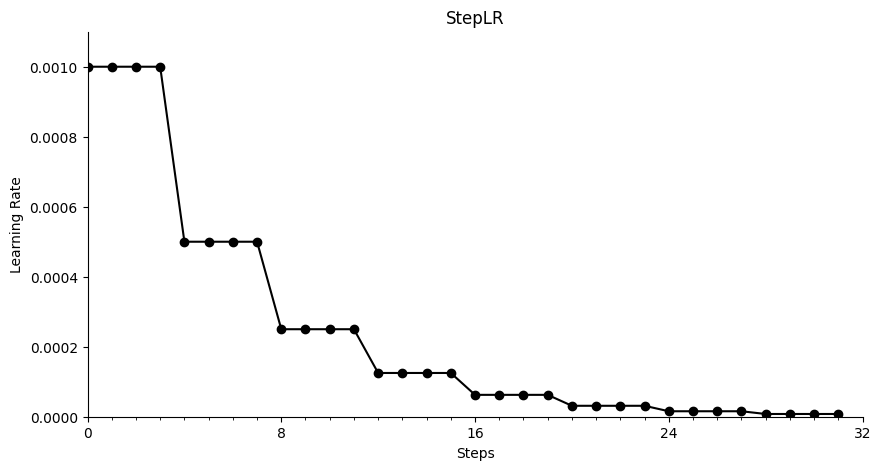

In [26]:
vis_lr_values(learning_rates_step, 'StepLR')

## ExponentialLR

Decays the learning rate of each parameter group by gamma every epoch.
$$
\begin{split}
&\eta_t = \gamma \eta_{t-1}\\
&\eta_t = \gamma^{t-1}\eta_1
\end{split}
$$

- 与 StepLR 相比，没有稳定阶段（stage）

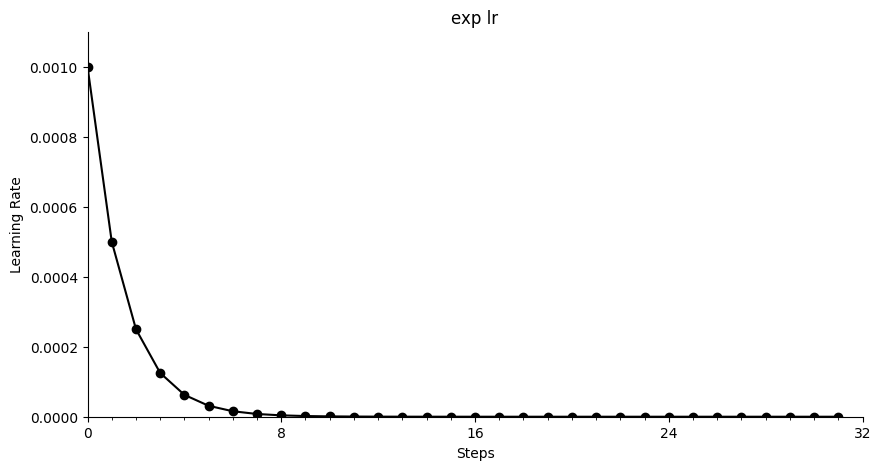

In [36]:
from torch.optim.lr_scheduler import ExponentialLR
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
scheduler = ExponentialLR(optimizer, gamma=0.5)
lr_values_exp = lr_step_values(scheduler)
vis_lr_values(lr_values_exp, 'exp lr')

ConstantLR

- factor 与 total_iters
    - 在初始的 total_iters 内，lr = lr * factor
    - 在 total_iters 之后，恢复到初始的 lr；

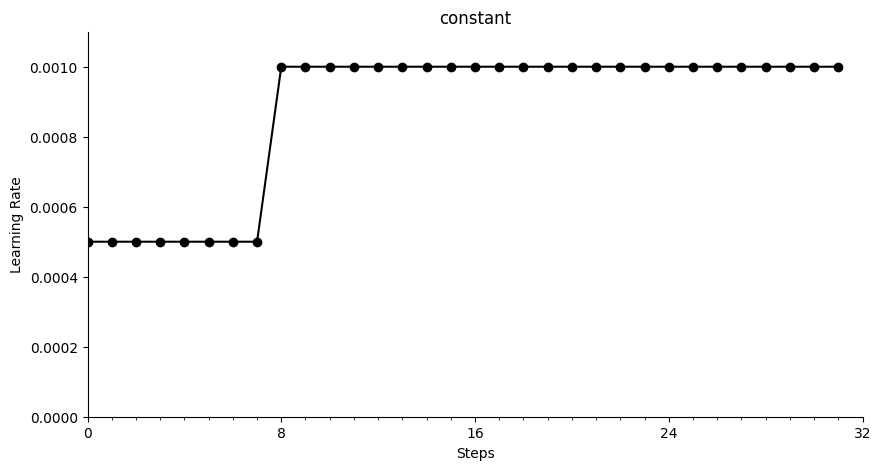

In [28]:
from torch.optim.lr_scheduler import ConstantLR
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
scheduler = ConstantLR(optimizer, factor=0.5, total_iters=8)
lr_values_constant = lr_step_values(scheduler)
vis_lr_values(lr_values_constant, 'constant')

LinearLR

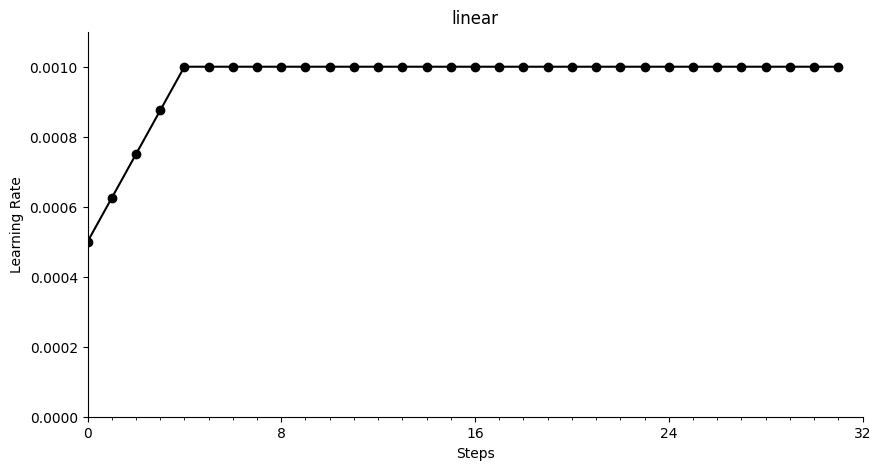

In [29]:
from torch.optim.lr_scheduler import LinearLR
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
scheduler = LinearLR(optimizer, start_factor=0.5, total_iters=4)
lr_values_linear = lr_step_values(scheduler)
vis_lr_values(lr_values_linear, 'linear')

## Cosine LR

- https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html
- CosineAnnealingLR vs. CosineAnnealingWarmRestarts
    - CosineAnnealingLR：周期性的
    - CosineAnnealingWarmRestarts：周期会不断变长
        - 4->8->16

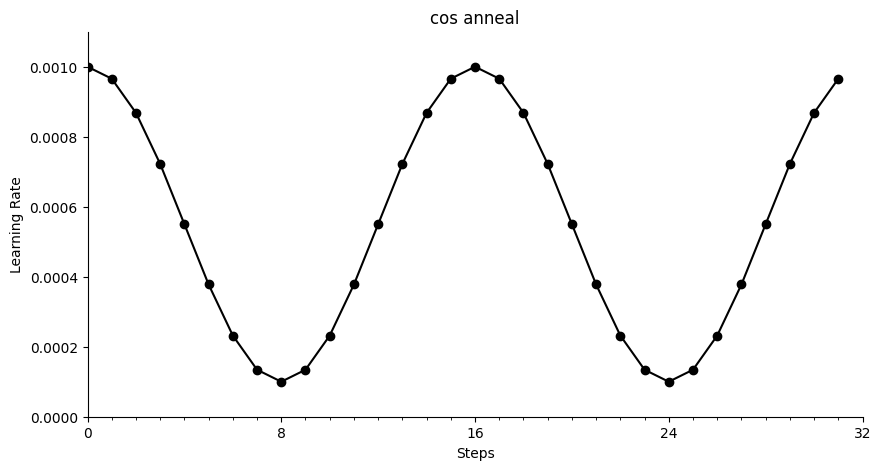

In [30]:
from torch.optim.lr_scheduler import CosineAnnealingLR
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
scheduler = CosineAnnealingLR(optimizer, T_max=8, eta_min=1e-4)
lr_values_cos = lr_step_values(scheduler)
vis_lr_values(lr_values_cos, 'cos anneal')

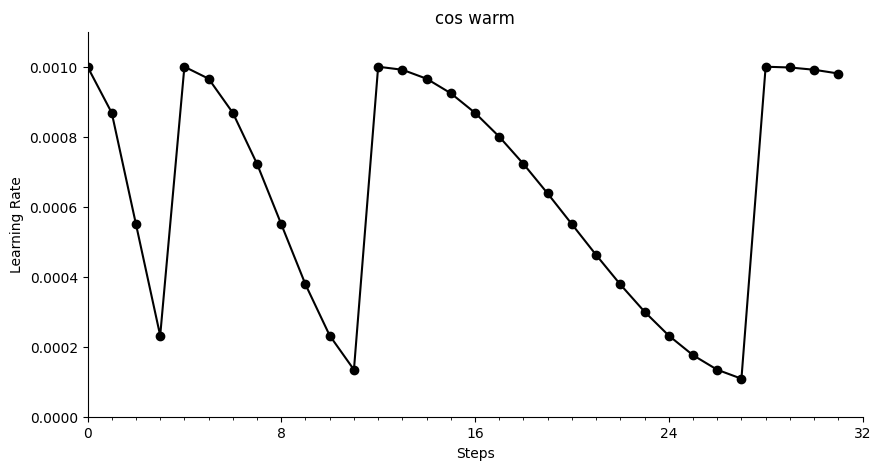

In [31]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=4, T_mult=2, eta_min=1e-4)
lr_values_cos_warm = lr_step_values(scheduler)
vis_lr_values(lr_values_cos_warm, 'cos warm')

## OneCycleLR, CyclicLR

- OneCycleLR：全局的调度

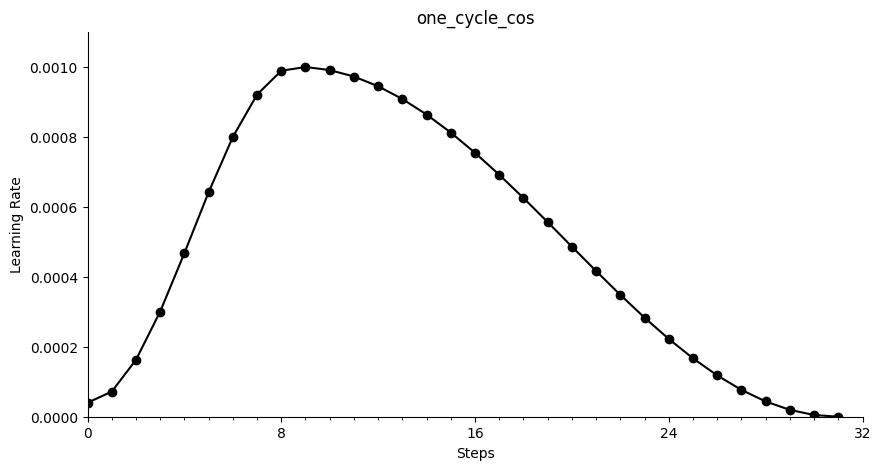

In [32]:
from torch.optim.lr_scheduler import OneCycleLR
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
scheduler = OneCycleLR(optimizer, 
                       max_lr=1e-3, 
                       epochs=4, steps_per_epoch=8, 
                       anneal_strategy='cos')
lr_values_one_cycle = lr_step_values(scheduler)
vis_lr_values(lr_values_one_cycle, 'one_cycle_cos')

4.000000000062981e-09


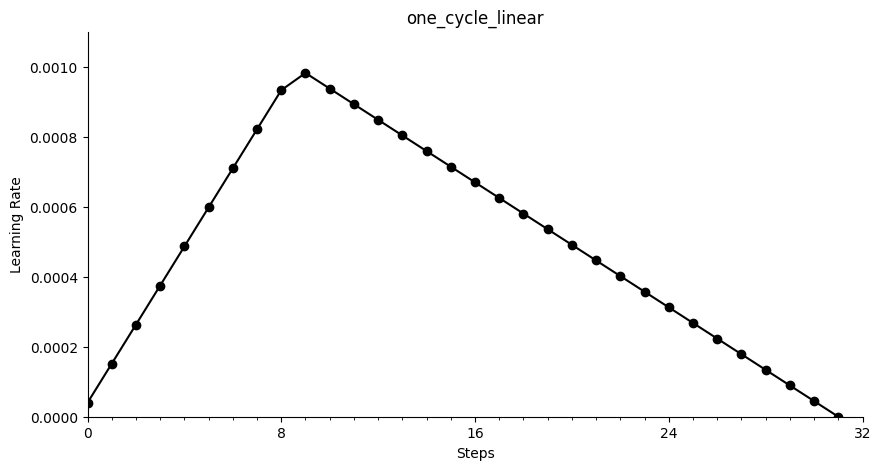

In [33]:
from torch.optim.lr_scheduler import OneCycleLR
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
scheduler = OneCycleLR(optimizer, 
                       max_lr=1e-3, 
                       epochs=4, steps_per_epoch=8, 
                       anneal_strategy='linear')
lr_values_one_cycle = lr_step_values(scheduler)
print(lr_values_one_cycle[-1])
vis_lr_values(lr_values_one_cycle, 'one_cycle_linear')

0.0001


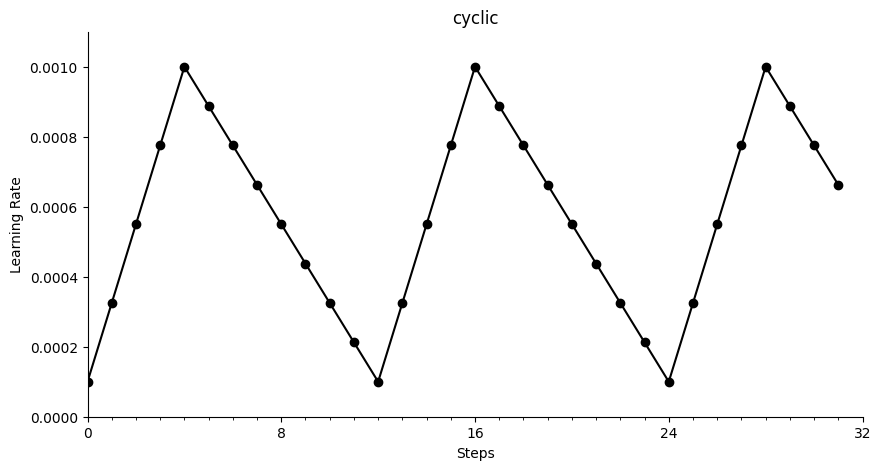

In [34]:
from torch.optim.lr_scheduler import CyclicLR
model = torch.nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
scheduler = CyclicLR(optimizer, base_lr=1e-4, max_lr=1e-3, 
                     step_size_up=4, step_size_down=8, 
                     mode='triangular')
lr_values_cyclic = lr_step_values(scheduler)
print(lr_values_cyclic[0])
vis_lr_values(lr_values_cyclic, 'cyclic')

## ReduceLROnPlateauLR

- reduces the learning rate by when the metric has stopped improving. 
    - 自适应的，adaptive；

[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]


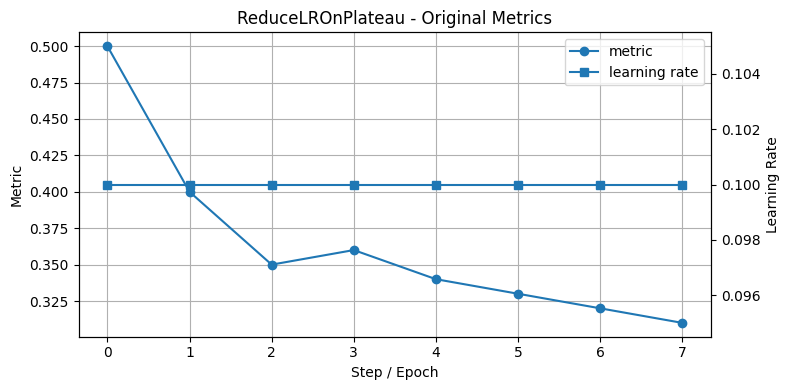

[0.1, 0.1, 0.1, 0.1, 0.1, 0.05, 0.05, 0.05, 0.05, 0.025, 0.025]


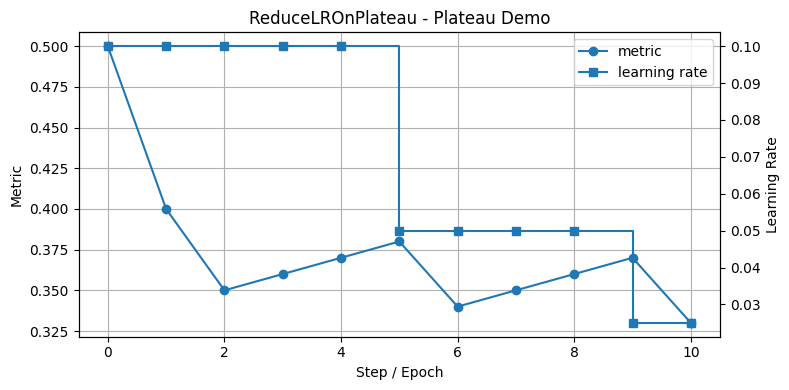

In [40]:
import torch
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau

LEARNING_RATE = 0.1

def run_reduce_on_plateau(metric_values, lr=LEARNING_RATE):
    model = torch.nn.Linear(2, 1)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2 # 允许连续 2 次不变好，超过这个次数才降学习率
    )

    lr_values = []

    for metric in metric_values:
        scheduler.step(metric)
        lr_values.append(optimizer.param_groups[0]["lr"])

    return lr_values


def vis_reduce_on_plateau(metric_values, lr_values, title="ReduceLROnPlateau"):
    steps = list(range(len(metric_values)))

    fig, ax1 = plt.subplots(figsize=(8, 4))

    ax1.plot(steps, metric_values, marker="o", label="metric")
    ax1.set_xlabel("Step / Epoch")
    ax1.set_ylabel("Metric")
    ax1.set_title(title)
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.step(steps, lr_values, where="post", marker="s", label="learning rate")
    ax2.set_ylabel("Learning Rate")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

    plt.tight_layout()
    plt.show()


# 你的原始例子：基本一直在变好，所以不会降 lr
metric_values = [0.5, 0.4, 0.35, 0.36, 0.34, 0.33, 0.32, 0.31]

lr_values_plateau = run_reduce_on_plateau(metric_values)
print(lr_values_plateau)

vis_reduce_on_plateau(
    metric_values,
    lr_values_plateau,
    title="ReduceLROnPlateau - Original Metrics"
)


# 更明显的 plateau 例子：连续不变好，触发降 lr
metric_values_plateau = [
    0.50, 0.40, 0.35,
    0.36, 0.37, 0.38,
    0.34,
    0.35, 0.36, 0.37,
    0.33
]

lr_values_plateau_demo = run_reduce_on_plateau(metric_values_plateau)
print(lr_values_plateau_demo)

vis_reduce_on_plateau(
    metric_values_plateau,
    lr_values_plateau_demo,
    title="ReduceLROnPlateau - Plateau Demo"
)